<center><h1>Lanka_VenkataSriSaiPavani_HW7</h1></center>

Name: Venkata Sri Sai Pavani Lanka
<br>
Github Username: lanka1908
<br>
USC ID: 4885549248

## 1. Multi-class and Multi-Label Classification Using Support Vector Machines

Import packages

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import hamming_loss, accuracy_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE
from scipy.spatial.distance import hamming
from sklearn.cluster import KMeans
from collections import Counter

### (a) Download the Anuran Calls (MFCCs) Data Set

In [7]:
data = pd.read_csv('../data/Anuran Calls (MFCCs)/Frogs_MFCCs.csv')

X = data.iloc[:, :-4]
y = data[['Family', 'Genus', 'Species']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

print("Training set size (X):", X_train.shape)
print("Training set size (y):", y_train.shape)
print("Test set size (X):", X_test.shape)
print("Test set size (y):", y_test.shape)

Training set size (X): (5036, 22)
Training set size (y): (5036, 3)
Test set size (X): (2159, 22)
Test set size (y): (2159, 3)


### (b) Train a classifier for each label

#### (i) Research

Exact match ratio: exact match evaluates if all the predicted labels exactly match the true labels. So it is the ratio of instances where all labels are correctly predicted to the total number of instances.

Hamming score: it evaluates the performance on each label independently and averages the results. It is the proportion of labels that are correctly predicted across all instances. hamming loss = 1 - hamming score.

#### (ii) Train a SVM for each of the labels

In [12]:
# Site Reference

y = y.apply(LabelEncoder().fit_transform)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

param_grid = {
    'estimator__C': np.logspace(-3, 3, num=5),  
    'estimator__gamma': np.linspace(0.1, 1.0, num=5)
}

def tune_svm_for_label(label):
    svc = SVC(kernel='rbf')
    one_vs_rest_svc = OneVsRestClassifier(svc)
    grid_search = GridSearchCV(one_vs_rest_svc, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
    
    grid_search.fit(X_train, y_train[label])
    
    print(f"Best parameters for {label}: {grid_search.best_params_}")
    print(f"Best cross-validated accuracy for {label}: {grid_search.best_score_}")
    
    return grid_search.best_estimator_

print("\nTraining data:")
family_clf = tune_svm_for_label('Family')
genus_clf = tune_svm_for_label('Genus')
species_clf = tune_svm_for_label('Species')

family_pred = family_clf.predict(X_test)
genus_pred = genus_clf.predict(X_test)
species_pred = species_clf.predict(X_test)

y_true = np.column_stack((y_test['Family'], y_test['Genus'], y_test['Species']))
y_pred = np.column_stack((family_pred, genus_pred, species_pred))

exact_match_score = np.mean(np.all(y_true == y_pred, axis=1))
print("Exact Match Score:", exact_match_score)

hamming_loss_value = np.mean(y_true != y_pred)
print("Overall Hamming Loss:", hamming_loss_value)

hamming_score = 1 - hamming_loss_value
print("Overall Hamming Score:", hamming_score)

family_hamming_loss = np.mean(y_test['Family'] != family_pred)
genus_hamming_loss = np.mean(y_test['Genus'] != genus_pred)
species_hamming_loss = np.mean(y_test['Species'] != species_pred)

print("\nHamming Loss for each label:")
print(f"Family: {family_hamming_loss}")
print(f"Genus: {genus_hamming_loss}")
print(f"Species: {species_hamming_loss}")

print("\nTest Accuracies:")
print("Family:", accuracy_score(y_test['Family'], family_pred))
print("Genus:", accuracy_score(y_test['Genus'], genus_pred))
print("Species:", accuracy_score(y_test['Species'], species_pred))


Training data:
Best parameters for Family: {'estimator__C': 31.622776601683793, 'estimator__gamma': 1.0}
Best cross-validated accuracy for Family: 0.9918587680267601
Best parameters for Genus: {'estimator__C': 31.622776601683793, 'estimator__gamma': 1.0}
Best cross-validated accuracy for Genus: 0.9898710909148285
Best parameters for Species: {'estimator__C': 31.622776601683793, 'estimator__gamma': 0.55}
Best cross-validated accuracy for Species: 0.9896722837577709
Exact Match Score: 0.9851783232978231
Overall Hamming Loss: 0.008645978076269878
Overall Hamming Score: 0.9913540219237301

Hamming Loss for each label:
Family: 0.005094951366373321
Genus: 0.009726725335803613
Species: 0.0111162575266327

Test Accuracies:
Family: 0.9949050486336267
Genus: 0.9902732746641963
Species: 0.9888837424733673


#### (iii) Repeat 1(b)ii with L1-penalized SVMs

In [14]:
# Site Reference

y = y.apply(LabelEncoder().fit_transform)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

param_grid = {'estimator__C': np.logspace(-3, 3, num=5)}

def tune_l1_svm_for_label(label):
    l1_svc = LinearSVC(penalty='l1', dual=False, max_iter=1000000)
    one_vs_rest_svc = OneVsRestClassifier(l1_svc)
    grid_search = GridSearchCV(one_vs_rest_svc, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
    
    grid_search.fit(X_train, y_train[label])
    
    print(f"Best parameters for {label} with L1 penalty: {grid_search.best_params_}")
    print(f"Best cross-validated accuracy for {label} with L1 penalty: {grid_search.best_score_}")
    
    return grid_search.best_estimator_

print("Training with L1-penalized SVMs:")
family_clf_l1 = tune_l1_svm_for_label('Family')
genus_clf_l1 = tune_l1_svm_for_label('Genus')
species_clf_l1 = tune_l1_svm_for_label('Species')

family_pred_l1 = family_clf_l1.predict(X_test)
genus_pred_l1 = genus_clf_l1.predict(X_test)
species_pred_l1 = species_clf_l1.predict(X_test)

y_true = np.column_stack((y_test['Family'], y_test['Genus'], y_test['Species']))
y_pred = np.column_stack((family_pred_l1, genus_pred_l1, species_pred_l1))

exact_match_score = np.mean(np.all(y_true == y_pred, axis=1))
print("Exact Match Score:", exact_match_score)

hamming_loss_value = np.mean(y_true != y_pred)
print("Overall Hamming Loss:", hamming_loss_value)

hamming_score = 1 - hamming_loss_value
print("Overall Hamming Score:", hamming_score)

family_hamming_loss = np.mean(y_test['Family'] != family_pred_l1)
genus_hamming_loss = np.mean(y_test['Genus'] != genus_pred_l1)
species_hamming_loss = np.mean(y_test['Species'] != species_pred_l1)

print("\nHamming Loss for each label:")
print(f"Family: {family_hamming_loss}")
print(f"Genus: {genus_hamming_loss}")
print(f"Species: {species_hamming_loss}")

print("\nL1-Penalized SVM Test Accuracies:")
print("Family:", accuracy_score(y_test['Family'], family_pred_l1))
print("Genus:", accuracy_score(y_test['Genus'], genus_pred_l1))
print("Species:", accuracy_score(y_test['Species'], species_pred_l1))

Training with L1-penalized SVMs:
Best parameters for Family with L1 penalty: {'estimator__C': 31.622776601683793}
Best cross-validated accuracy for Family with L1 penalty: 0.9406288459717883
Best parameters for Genus with L1 penalty: {'estimator__C': 31.622776601683793}
Best cross-validated accuracy for Genus with L1 penalty: 0.9527422764997319
Best parameters for Species with L1 penalty: {'estimator__C': 1000.0}
Best cross-validated accuracy for Species with L1 penalty: 0.960285509167219
Exact Match Score: 0.9119962945808244
Overall Hamming Loss: 0.05727960475528794
Overall Hamming Score: 0.9427203952447121

Hamming Loss for each label:
Family: 0.07225567392311255
Genus: 0.058360352014821676
Species: 0.041222788327929596
L1-Penalized SVM Test Accuracies:
Family: 0.9277443260768874
Genus: 0.9416396479851783
Species: 0.9587772116720704


#### (iv) Repeat 1(b)iii by using SMOTE or any other method for imbalance

In [16]:
# Site & Chatgpt Reference

y = y.apply(LabelEncoder().fit_transform)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

smote = SMOTE(random_state=42)
X_train_family, y_train_family = smote.fit_resample(X_train, y_train['Family'])
X_train_genus, y_train_genus = smote.fit_resample(X_train, y_train['Genus'])
X_train_species, y_train_species = smote.fit_resample(X_train, y_train['Species'])

param_grid = {'estimator__C': np.logspace(-3, 3, num=5)}

def tune_l1_svm_smote(X_balanced, y_balanced, label):
    l1_svc = LinearSVC(penalty='l1', dual=False, max_iter=1000000)
    one_vs_rest_svc = OneVsRestClassifier(l1_svc)
    grid_search = GridSearchCV(one_vs_rest_svc, param_grid, cv=10, scoring='accuracy', n_jobs=-1)
    
    grid_search.fit(X_balanced, y_balanced)
    
    print(f"Best parameters for {label} with SMOTE: {grid_search.best_params_}")
    print(f"Best cross-validated accuracy for {label} with SMOTE: {grid_search.best_score_}")
    
    return grid_search.best_estimator_

print("Training with L1-penalized SVMs and SMOTE:")
family_clf_smote = tune_l1_svm_smote(X_train_family, y_train_family, 'Family')
genus_clf_smote = tune_l1_svm_smote(X_train_genus, y_train_genus, 'Genus')
species_clf_smote = tune_l1_svm_smote(X_train_species, y_train_species, 'Species')

family_pred_smote = family_clf_smote.predict(X_test)
genus_pred_smote = genus_clf_smote.predict(X_test)
species_pred_smote = species_clf_smote.predict(X_test)

y_true = np.column_stack((y_test['Family'], y_test['Genus'], y_test['Species']))
y_pred = np.column_stack((family_pred_smote, genus_pred_smote, species_pred_smote))

exact_match_score = np.mean(np.all(y_true == y_pred, axis=1))
print("Exact Match Score:", exact_match_score)

hamming_loss_value = np.mean(y_true != y_pred)
print("Overall Hamming Loss:", hamming_loss_value)

hamming_score = 1 - hamming_loss_value
print("Overall Hamming Score:", hamming_score)

family_hamming_loss = np.mean(y_test['Family'] != family_pred_smote)
genus_hamming_loss = np.mean(y_test['Genus'] != genus_pred_smote)
species_hamming_loss = np.mean(y_test['Species'] != species_pred_smote)

print("\nHamming Loss for each label:")
print(f"Family: {family_hamming_loss}")
print(f"Genus: {genus_hamming_loss}")
print(f"Species: {species_hamming_loss}")

print("SMOTE Data Test Accuracies:")
print("Family:", accuracy_score(y_test['Family'], family_pred_smote))
print("Genus:", accuracy_score(y_test['Genus'], genus_pred_smote))
print("Species:", accuracy_score(y_test['Species'], species_pred_smote))

Training with L1-penalized SVMs and SMOTE:
Best parameters for Family with SMOTE: {'estimator__C': 31.622776601683793}
Best cross-validated accuracy for Family with SMOTE: 0.9509444521621783
Best parameters for Genus with SMOTE: {'estimator__C': 31.622776601683793}
Best cross-validated accuracy for Genus with SMOTE: 0.9569684279787662
Best parameters for Species with SMOTE: {'estimator__C': 1000.0}
Best cross-validated accuracy for Species with SMOTE: 0.9630159378831223
Exact Match Score: 0.8554886521537749
Overall Hamming Loss: 0.07580670063300911
Overall Hamming Score: 0.9241932993669909

Hamming Loss for each label:
Family: 0.09124594719777675
Genus: 0.0968040759610931
Species: 0.03937007874015748
SMOTE Data Test Accuracies:
Family: 0.9087540528022232
Genus: 0.9031959240389069
Species: 0.9606299212598425


## 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

### (a) Use k-means clustering

In [19]:
# Site & Chatgpt Reference

X = data.select_dtypes(include=[np.number]) 
y = data[['Family', 'Genus', 'Species']]

y_encoded = y.apply(LabelEncoder().fit_transform)

num_simulations = 50
hamming_distances = []

for sim in range(num_simulations):
    silhouette_scores = []
    k_values = range(1, 51)
    
    for k in k_values:
        if k == 1:
            silhouette_scores.append(float('-inf'))
        else:
            kmeans = KMeans(n_clusters=k, random_state=42) 
            labels = kmeans.fit_predict(X)
            score = silhouette_score(X, labels)
            silhouette_scores.append(score)
    
    optimal_k = k_values[np.argmax(silhouette_scores[1:]) + 1]
    print(f"Simulation {sim + 1}: Optimal number of clusters (k) based on Silhouette Score: {optimal_k}")

    kmeans = KMeans(n_clusters=optimal_k, random_state=None) 
    cluster_labels = kmeans.fit_predict(X)

    family_hamming = hamming(y_encoded['Family'], cluster_labels)
    genus_hamming = hamming(y_encoded['Genus'], cluster_labels)
    species_hamming = hamming(y_encoded['Species'], cluster_labels)
    
    avg_hamming = np.mean([family_hamming, genus_hamming, species_hamming])
    hamming_distances.append(avg_hamming)

hamming_mean = np.mean(hamming_distances)
hamming_std = np.std(hamming_distances)

print(f"Average Hamming Distance over 50 simulations: {hamming_mean}")
print(f"Standard Deviation of Hamming Distance over 50 simulations: {hamming_std}")

Simulation 1: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 2: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 3: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 4: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 5: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 6: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 7: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 8: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 9: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 10: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 11: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 12: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 13: Optimal number of clusters (k) based on Silhouette Score: 2
Simulation 14: Optimal number of c

### (b) Determine which family is the majority

In [36]:
# Chatgpt Reference

y_encoded = y.apply(LabelEncoder().fit_transform)

num_simulations = 50 
for iteration in range(1, num_simulations + 1):
    print(f"\nIteration {iteration}")
    
    kmeans = KMeans(n_clusters=optimal_k, random_state=None)
    cluster_labels = kmeans.fit_predict(X)
    data['Cluster'] = cluster_labels

    print(f"Optimal k = {optimal_k}")

    for cluster in range(optimal_k):
        cluster_data = data[data['Cluster'] == cluster]
        cluster_size = len(cluster_data)
        
        family_counts = Counter(y_encoded.loc[cluster_data.index, 'Family'])
        genus_counts = Counter(y_encoded.loc[cluster_data.index, 'Genus'])
        species_counts = Counter(y_encoded.loc[cluster_data.index, 'Species'])
        
        majority_family = family_counts.most_common(1)[0]
        majority_genus = genus_counts.most_common(1)[0]
        majority_species = species_counts.most_common(1)[0]

        majority_family_percentage = (majority_family[1] / cluster_size) * 100
        majority_genus_percentage = (majority_genus[1] / cluster_size) * 100
        majority_species_percentage = (majority_species[1] / cluster_size) * 100

        print(f"\nCluster {cluster} Analysis:")
        print(f"Cluster size: {cluster_size} samples")
        print(f"Majority Family: {list(y['Family'].unique())[majority_family[0]]} ({majority_family_percentage:.2f}%)")
        print(f"Majority Genus: {list(y['Genus'].unique())[majority_genus[0]]} ({majority_genus_percentage:.2f}%)")
        print(f"Majority Species: {list(y['Species'].unique())[majority_species[0]]} ({majority_species_percentage:.2f}%)")


Iteration 1...
Optimal k = 2

Cluster 0 Analysis:
Cluster size: 4840 samples
Majority Family: Bufonidae (85.74%)
Majority Genus: Adenomera (85.74%)
Majority Species: Ameeregatrivittata (71.86%)

Cluster 1 Analysis:
Cluster size: 2355 samples
Majority Family: Hylidae (85.65%)
Majority Genus: Hypsiboas (67.64%)
Majority Species: HypsiboasCordobae (47.60%)

Iteration 2...
Optimal k = 2

Cluster 0 Analysis:
Cluster size: 4840 samples
Majority Family: Bufonidae (85.74%)
Majority Genus: Adenomera (85.74%)
Majority Species: Ameeregatrivittata (71.86%)

Cluster 1 Analysis:
Cluster size: 2355 samples
Majority Family: Hylidae (85.65%)
Majority Genus: Hypsiboas (67.64%)
Majority Species: HypsiboasCordobae (47.60%)

Iteration 3...
Optimal k = 2

Cluster 0 Analysis:
Cluster size: 2355 samples
Majority Family: Hylidae (85.65%)
Majority Genus: Hypsiboas (67.64%)
Majority Species: HypsiboasCordobae (47.60%)

Cluster 1 Analysis:
Cluster size: 4840 samples
Majority Family: Bufonidae (85.74%)
Majority G

### (c) Calculate the average Hamming distance, Hamming score, and Hamming loss

In [46]:
# Chatgpt Reference

y_encoded = y.apply(LabelEncoder().fit_transform)

num_simulations = 50
hamming_distances = []
hamming_losses = []
hamming_scores = []

for iteration in range(1, num_simulations + 1):   
    kmeans = KMeans(n_clusters=optimal_k, random_state=None)
    cluster_labels = kmeans.fit_predict(X)
    data['Cluster'] = cluster_labels
    majority_family = {}
    majority_genus = {}
    majority_species = {}

    for cluster in range(optimal_k):
        cluster_data = data[data['Cluster'] == cluster]

        family_counts = Counter(y_encoded.loc[cluster_data.index, 'Family'])
        genus_counts = Counter(y_encoded.loc[cluster_data.index, 'Genus'])
        species_counts = Counter(y_encoded.loc[cluster_data.index, 'Species'])

        majority_family[cluster] = family_counts.most_common(1)[0][0]
        majority_genus[cluster] = genus_counts.most_common(1)[0][0]
        majority_species[cluster] = species_counts.most_common(1)[0][0]

    predicted_labels = []
    for i in range(len(data)):
        cluster = data['Cluster'].iloc[i]
        predicted_labels.append((
            majority_family[cluster],
            majority_genus[cluster],
            majority_species[cluster]
        ))

    predicted_labels = np.array(predicted_labels)
    true_labels = y_encoded.to_numpy()

    iteration_hamming_distance = np.mean([
        hamming(true, pred) for true, pred in zip(true_labels, predicted_labels)
    ])
    iteration_hamming_loss = np.mean(true_labels != predicted_labels)
    iteration_hamming_score = 1 - iteration_hamming_loss

    hamming_distances.append(iteration_hamming_distance)
    hamming_losses.append(iteration_hamming_loss)
    hamming_scores.append(iteration_hamming_score)

avg_hamming_distance = np.mean(hamming_distances)
std_hamming_distance = np.std(hamming_distances)

avg_hamming_loss = np.mean(hamming_losses)
std_hamming_loss = np.std(hamming_losses)

avg_hamming_score = np.mean(hamming_scores)
std_hamming_score = np.std(hamming_scores)

print("\nFinal Results over 50 Simulations:")
print(f"Average Hamming Distance: {avg_hamming_distance:}")
print(f"Average Hamming Loss: {avg_hamming_loss:}") 
print(f"Average Hamming Score: {avg_hamming_score:}")


Final Results over 50 Simulations:
Average Hamming Distance: 0.23516330785267542
Average Hamming Loss: 0.23516330785267542
Average Hamming Score: 0.7648366921473246


## 3. ISLR 12.6.2

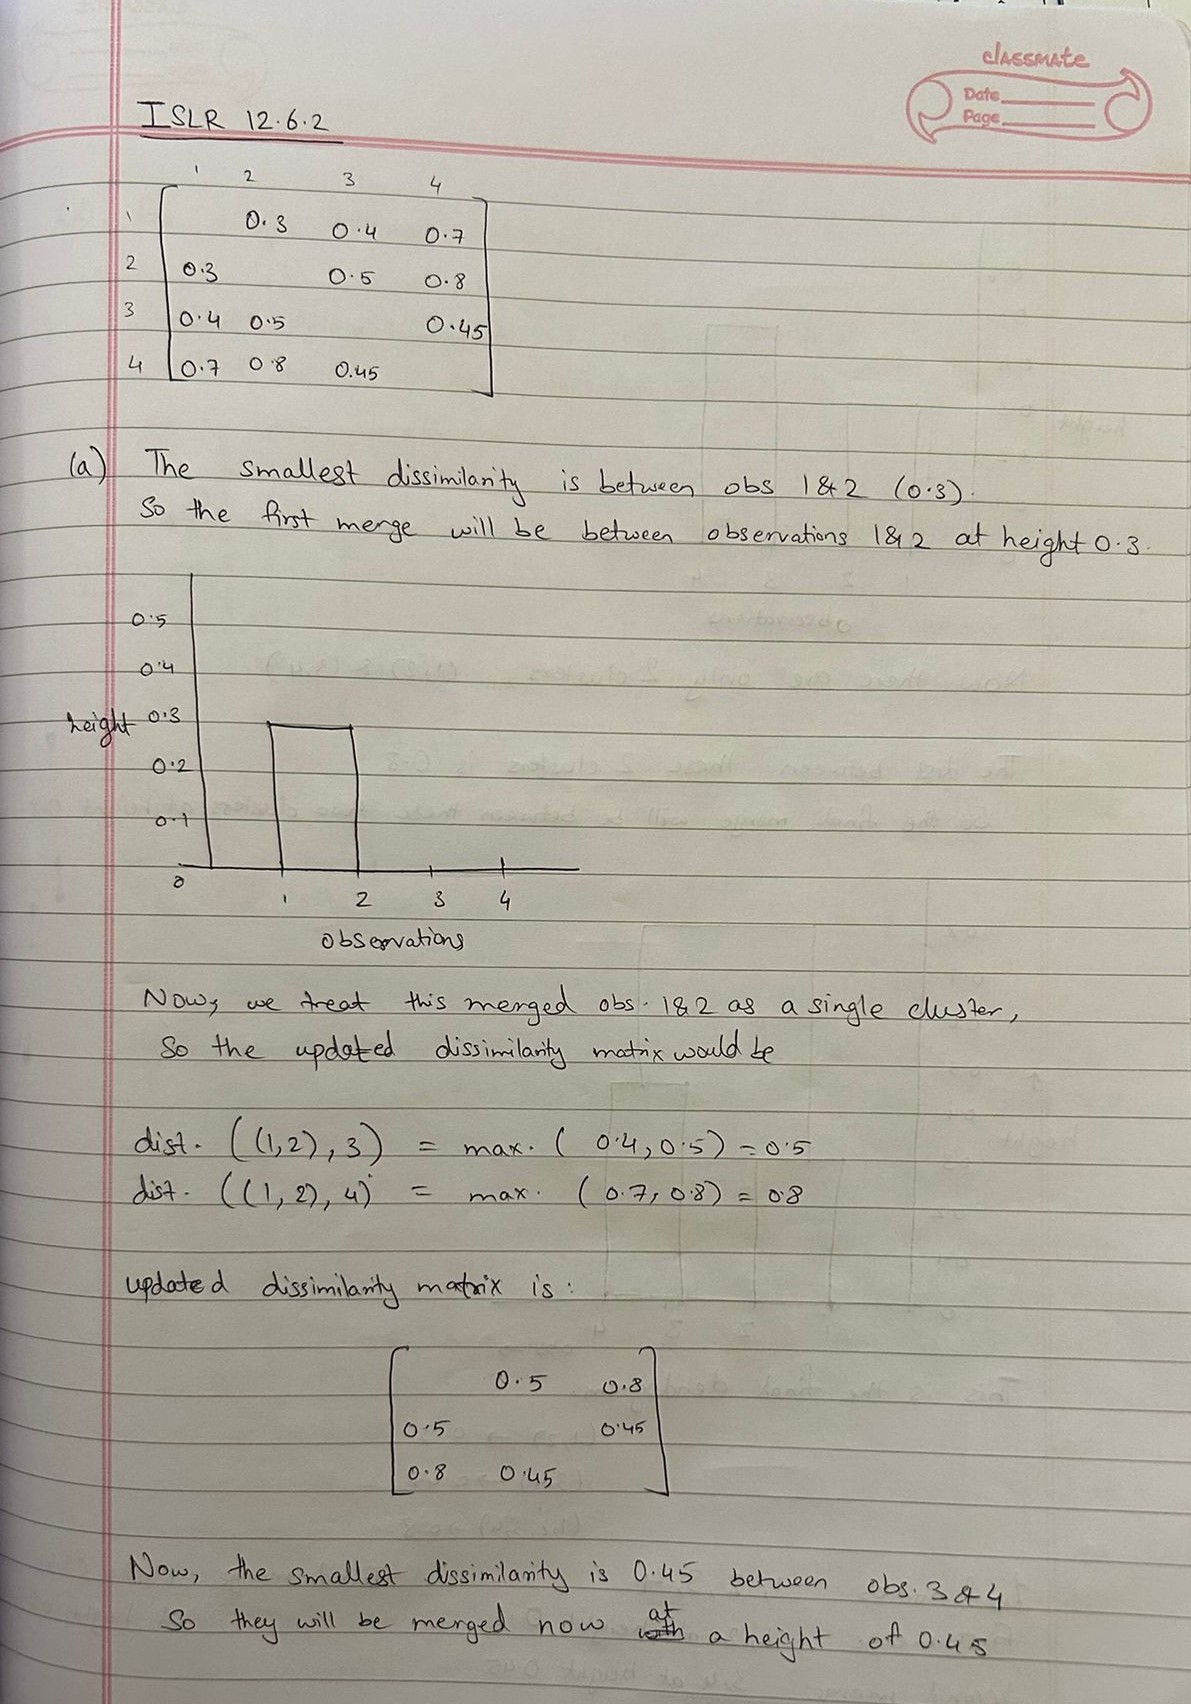
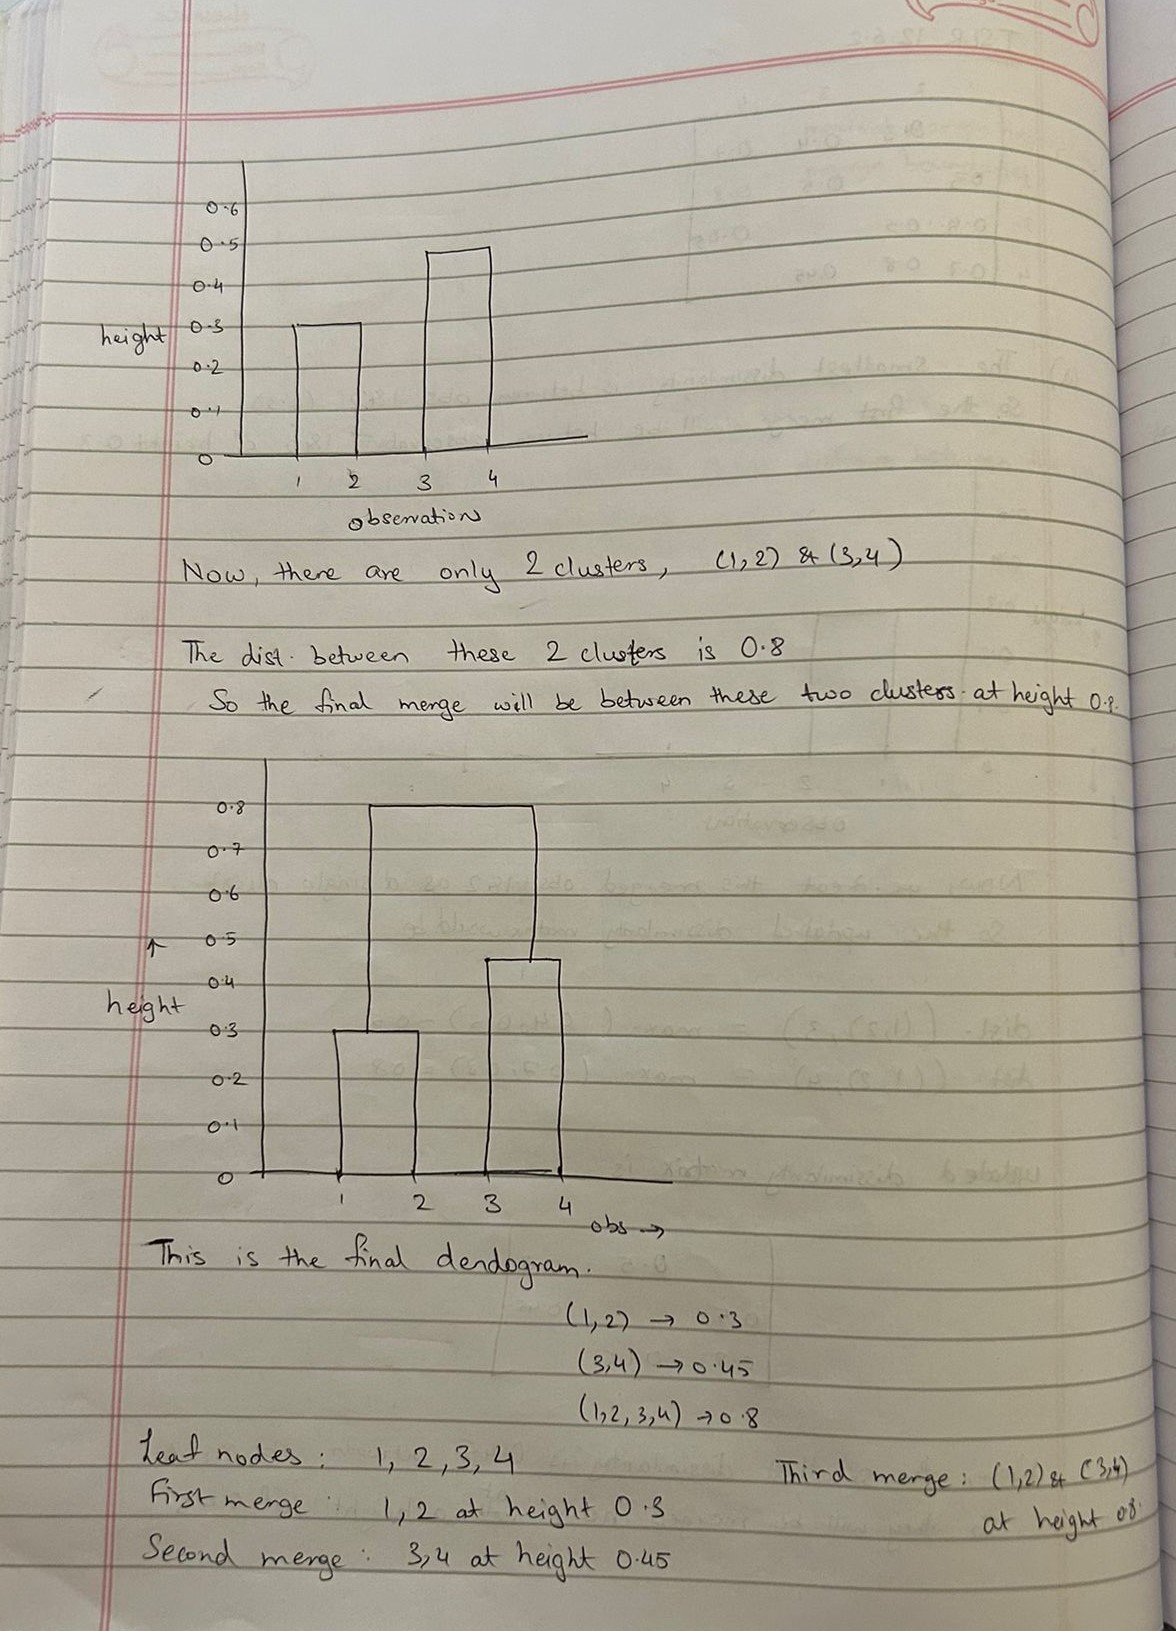
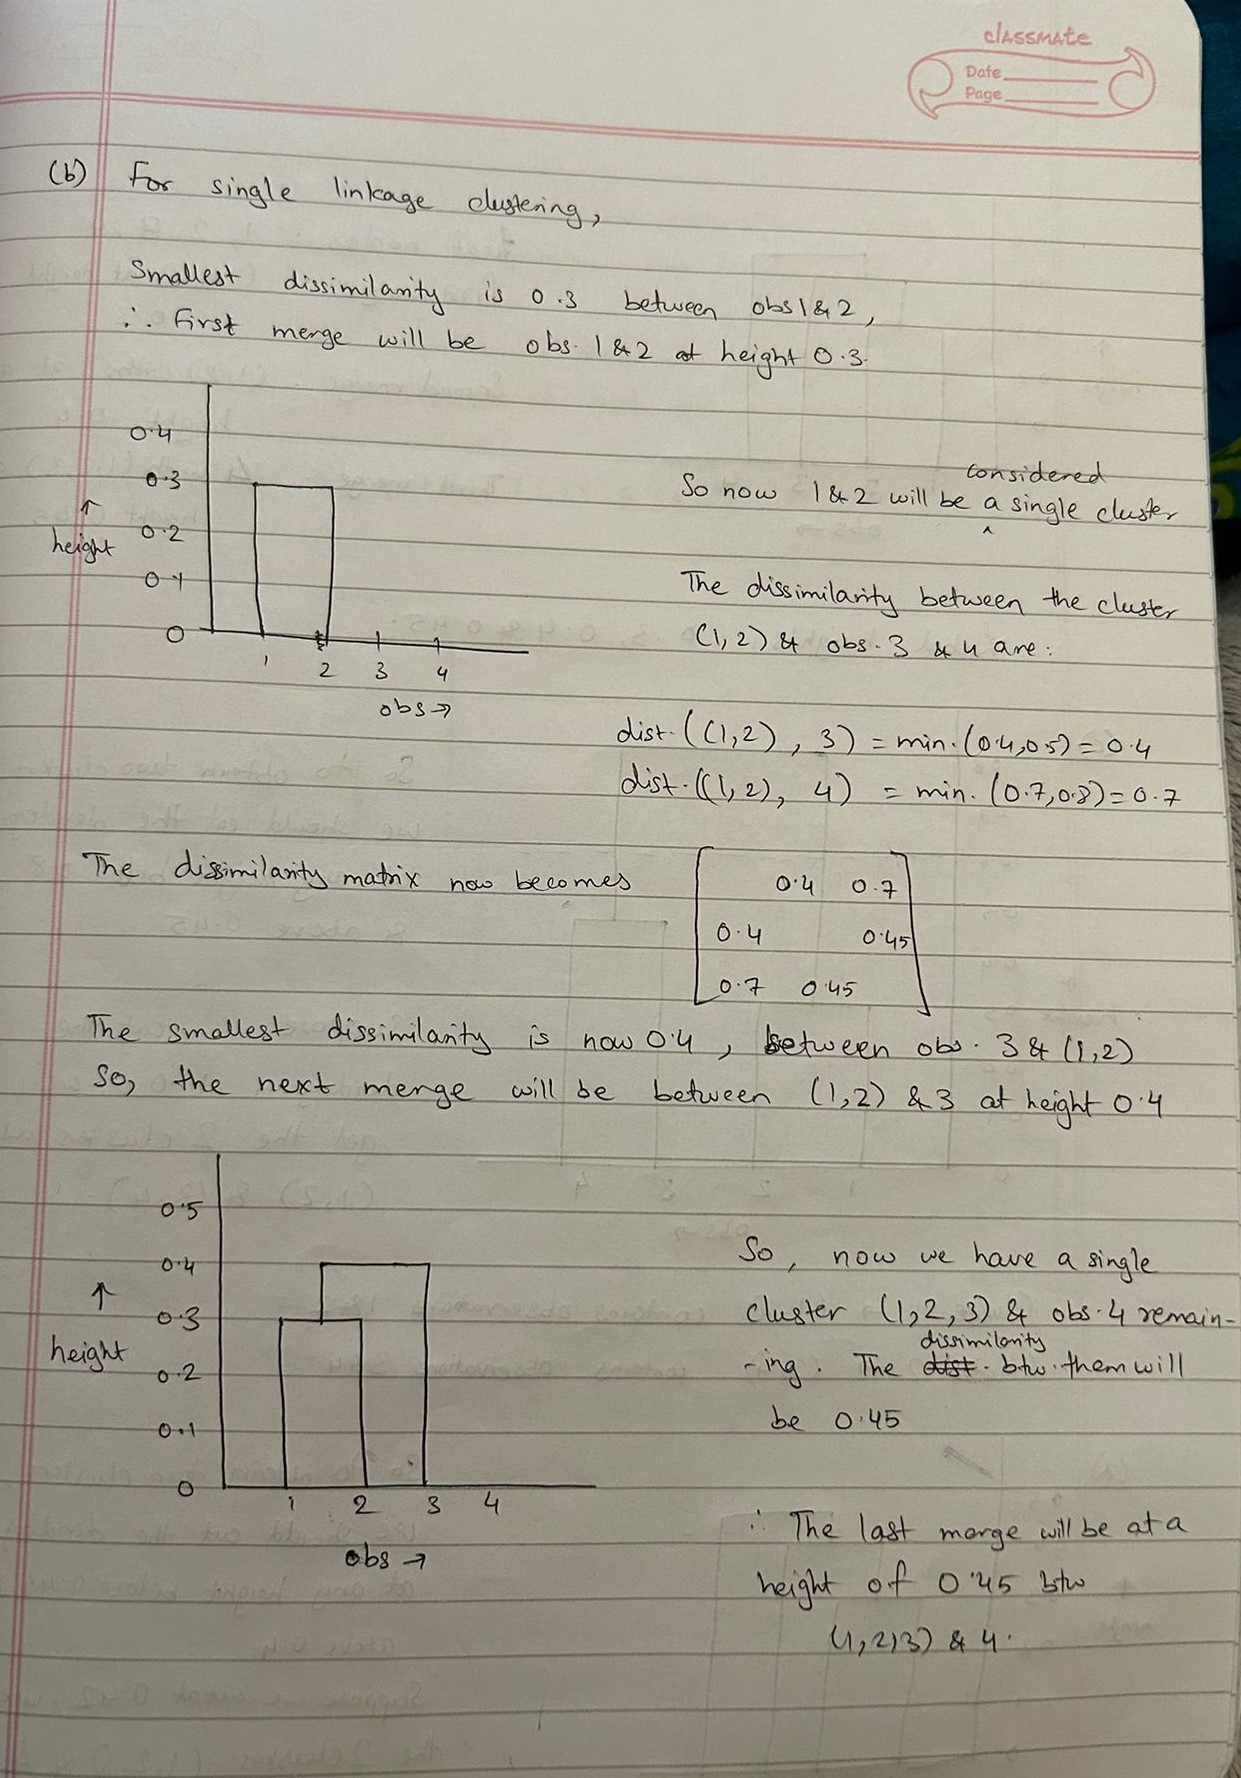
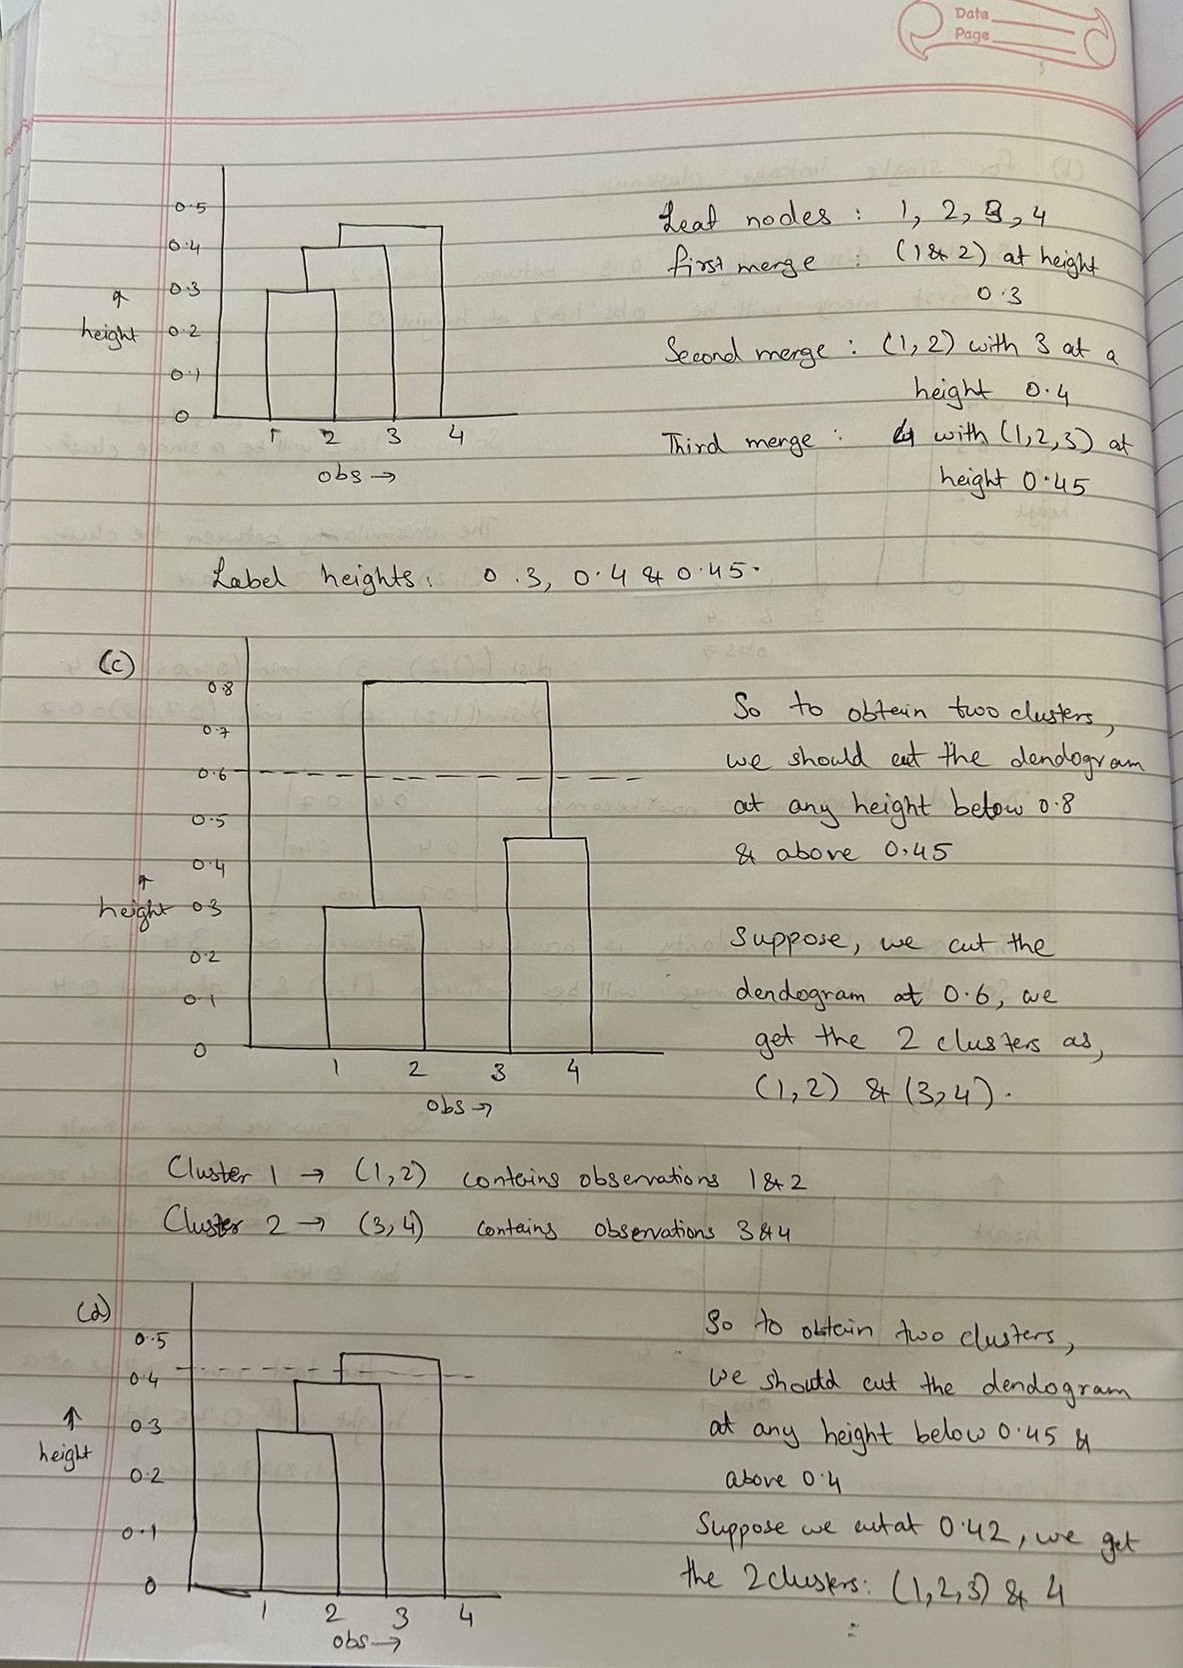
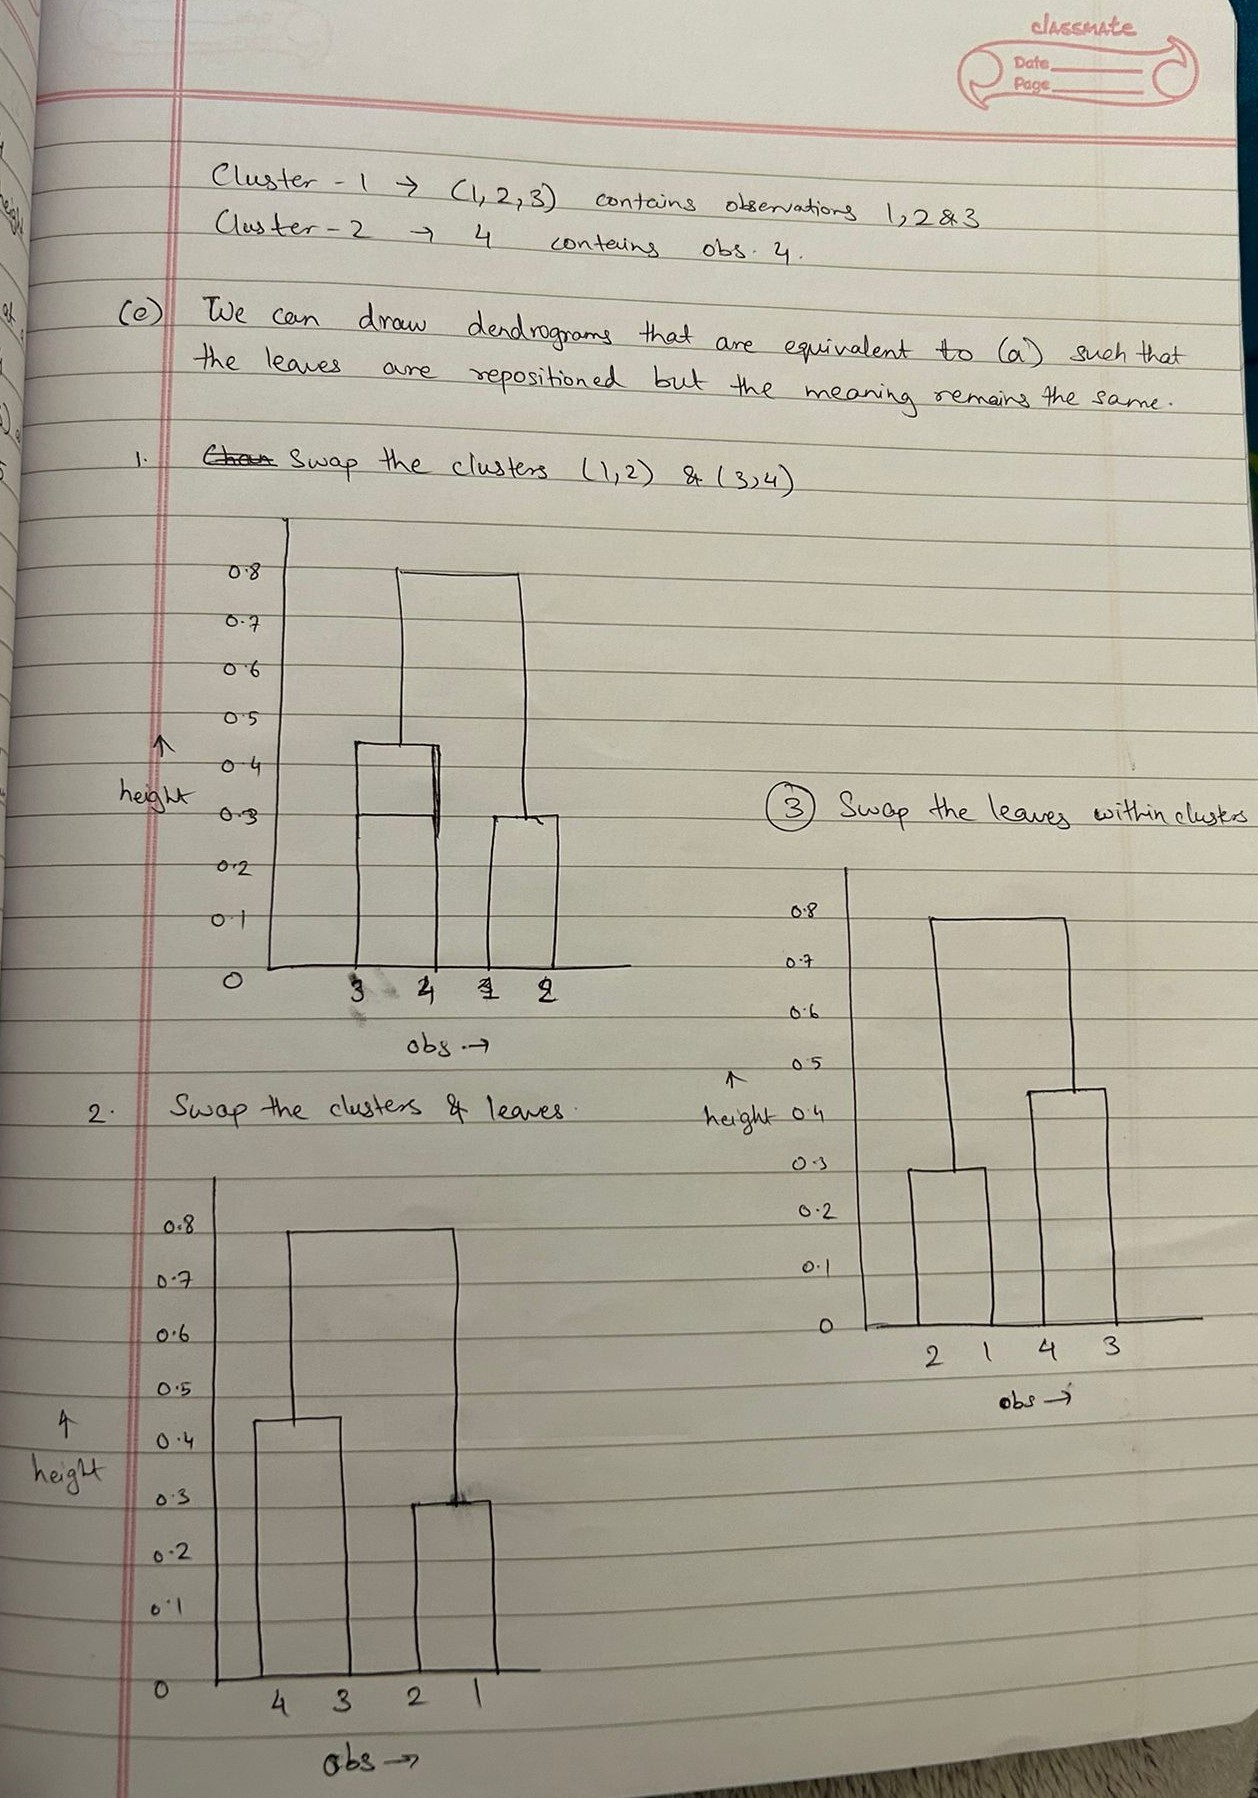

### Citations & References

1.b.i. 

https://www.analyticsvidhya.com/blog/2017/08/introduction-to-multi-label-classification/
https://mmuratarat.github.io/2020-01-25/multilabel_classification_metrics
https://machinelearningmastery.com/one-vs-rest-and-one-vs-one-for-multi-class-classification/

1.b.ii. 
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
https://scikit-learn.org/1.5/modules/svm.html
https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html

1.b.iii.

https://scikit-learn.org/stable/modules/multiclass.html#one-vs-the-rest
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
https://scikit-learn.org/dev/modules/generated/sklearn.svm.LinearSVC.html

1.b.iv.
https://scikit-learn.org/stable/modules/multiclass.html#one-vs-the-rest
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
https://scikit-learn.org/dev/modules/generated/sklearn.svm.LinearSVC.html

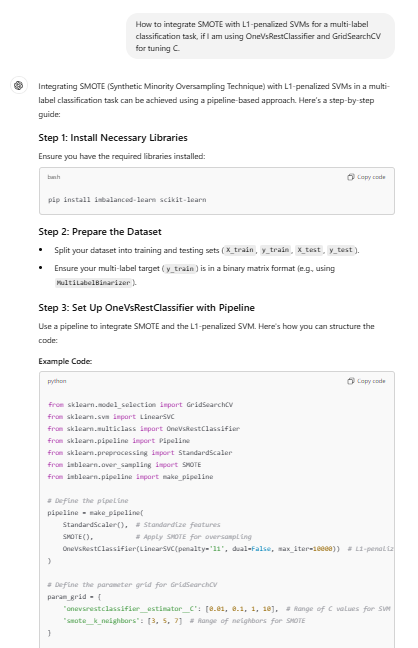

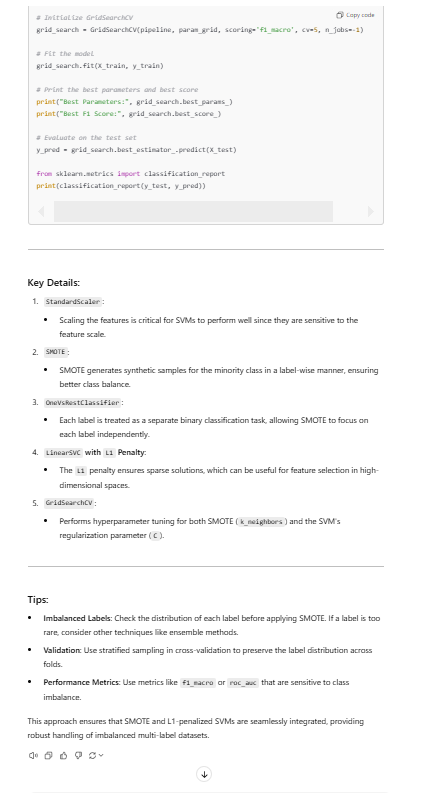

2.a.

https://www.analyticsvidhya.com/blog/2021/04/k-means-clustering-simplified-in-python/
https://realpython.com/k-means-clustering-python/
https://scikit-learn.org/1.5/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

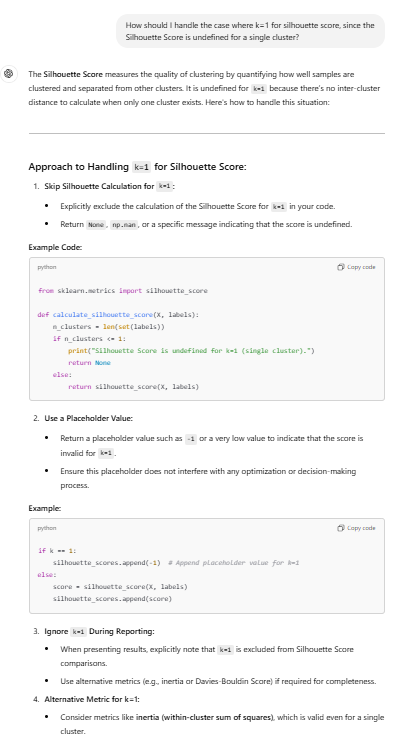

2.b.

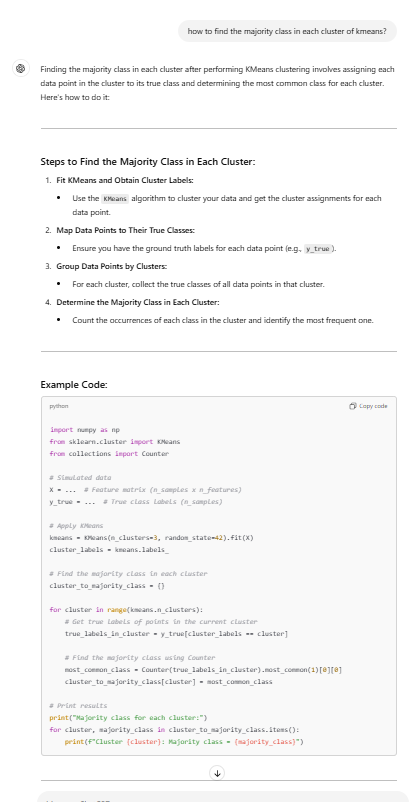

2.c.

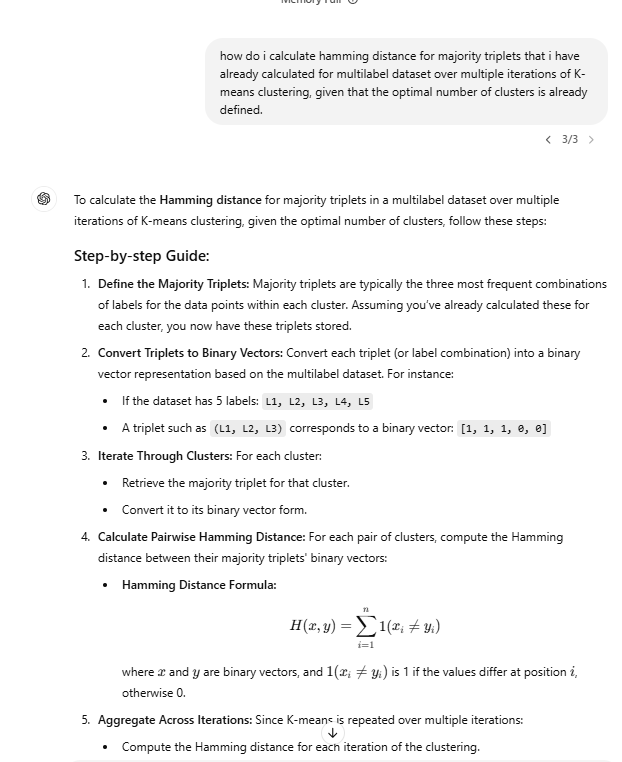

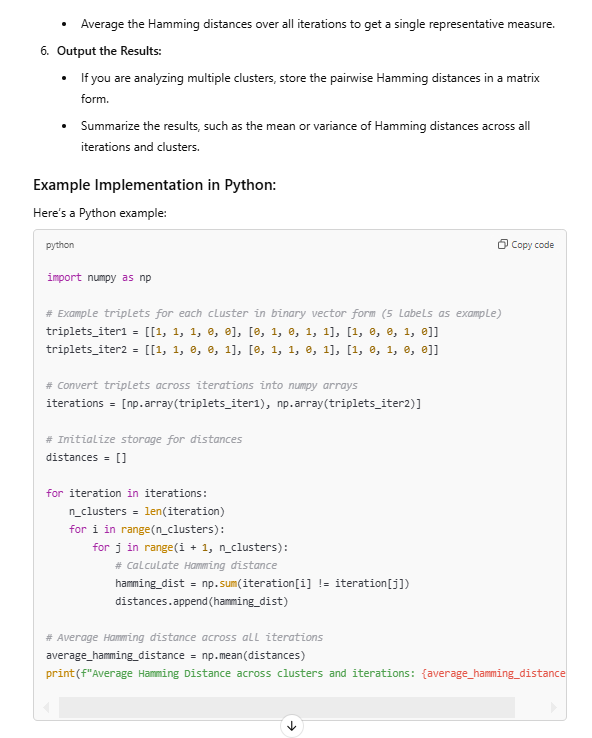